<a href="https://colab.research.google.com/github/pixi2102/iad-intro-ds/blob/master/_hw05_gd_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [1]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import t


## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [2]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [3]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        loss=np.mean((X.dot(w)-y)**2)
        return loss

        # -- YOUR CODE HERE -- ( ⚆ ω ⚆)
        # Вычислите значение функции потерь при помощи X, y и w и верните его

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        gradient=2*(X.T.dot(X.dot(w)-y))/len(y)
        return gradient
        # -- YOUR CODE HERE -- =^･ω･^=
        # Вычислите значение вектора градиента при помощи X, y и w и верните его

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [4]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [5]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """

    w=w_init
    t=[]
    for i in range(n_iterations):
      t.append(w)
      gradient=loss.calc_grad(X,y,w)
      w=w-lr*gradient

    return t
    # -- YOUR CODE HERE -- (ﾉ´ з `)ノ

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [6]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [7]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.58917680450253
0.8670644395649652


Здесь мне мой одногруппник подсказал изменить xlim, ylim на +-2, чтобы графики были менее сжатыми.

In [8]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(-2,2)
    plt.ylim(-2,2)
    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

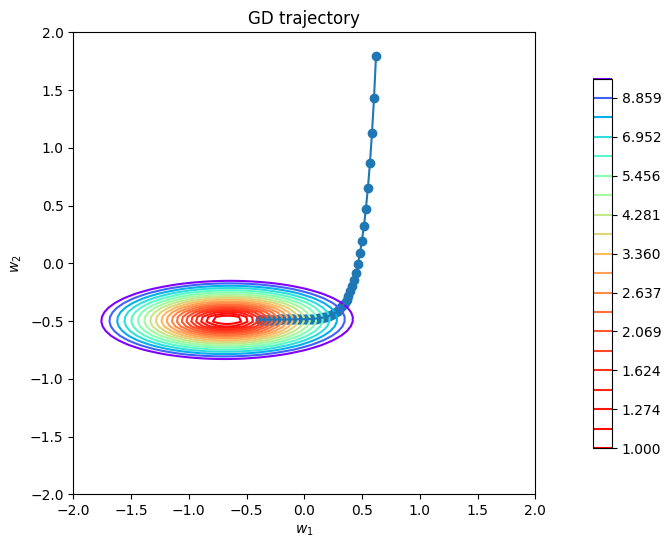

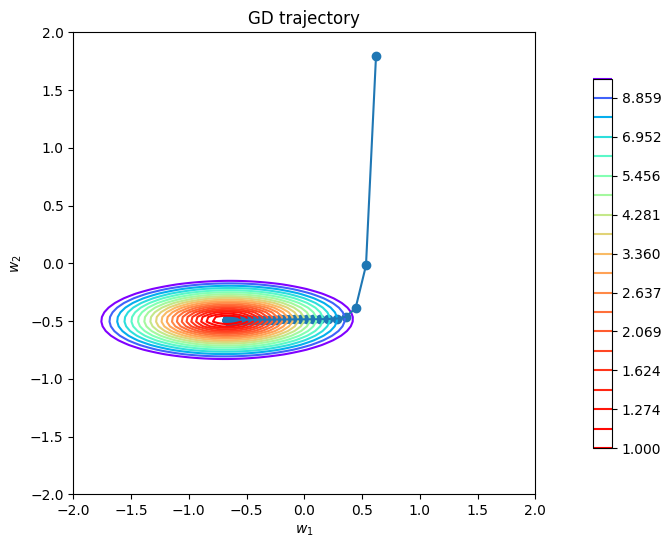

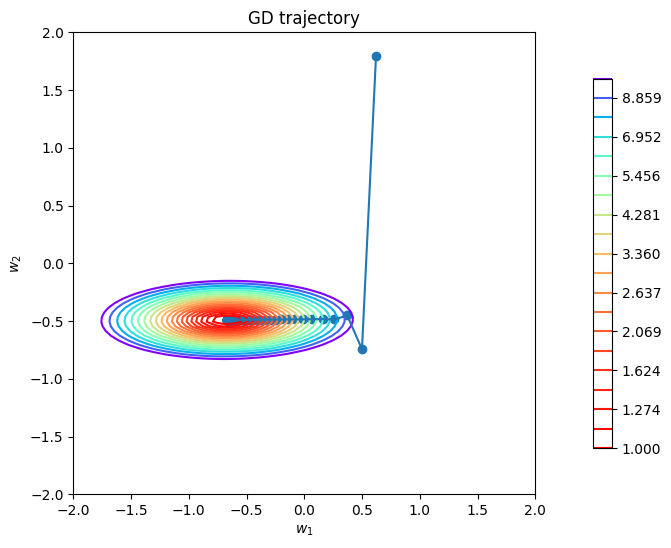

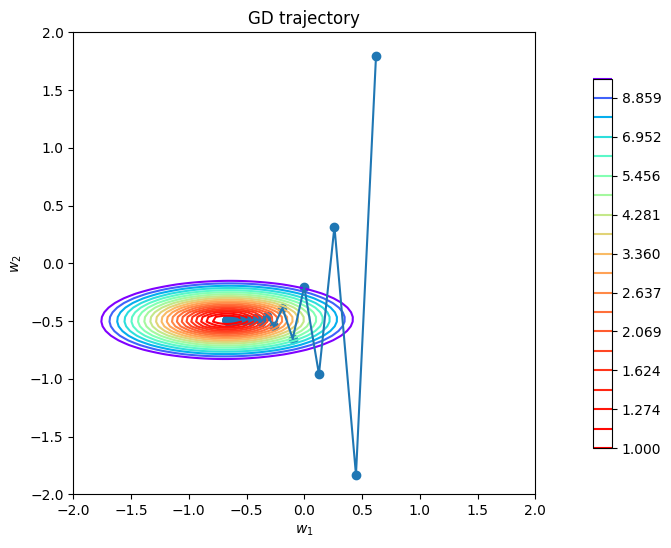

In [9]:
loss = MSELoss()
for lr in [0.001,0.005,0.007,0.01]:
  w=gradient_descent(w_init, X, y, loss, lr,100)
  plot_gd(w, X, y, loss)


Видим, что по мере увеличения шага изменения градиента становятся более значительными (то есть чем больше шаг, тем быстрее мы идем к минимуму). Однако при меньшем шаге меньше вероятность 'проскачить' минимум, а при большом шаге есть риск, что мы никогда к нему не сойдемся, так как будем его 'проскакивать'.

Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [10]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    t=[w_init]
    w=w_init.copy()
    n_objects = X.shape[0]
    for i in range(n_iterations):
        indices = np.random.choice(n_objects, size=batch_size, replace=False)
        X_batch = X[indices]
        y_batch = y[indices]
        gradient = loss.calc_grad(X_batch, y_batch, w)
        w = w - lr * gradient
        t.append(w)
    return t
    # -- YOUR CODE HERE -- (＠_＠)

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

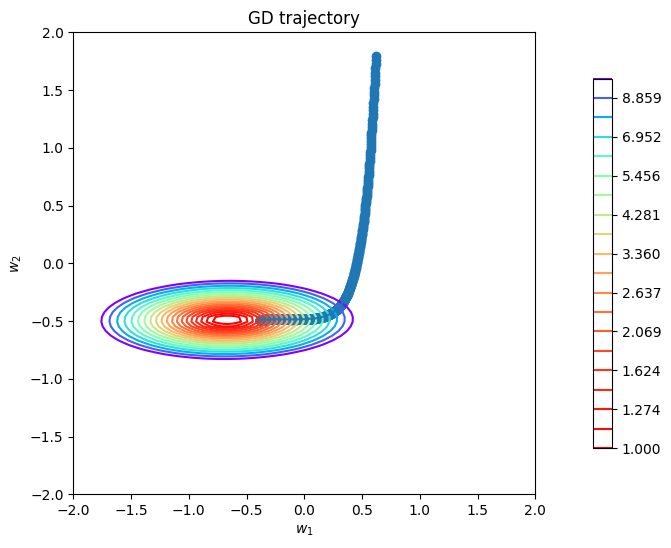

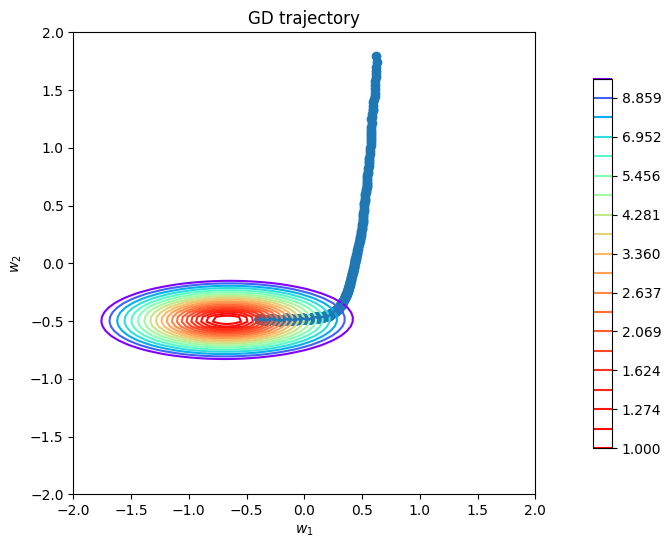

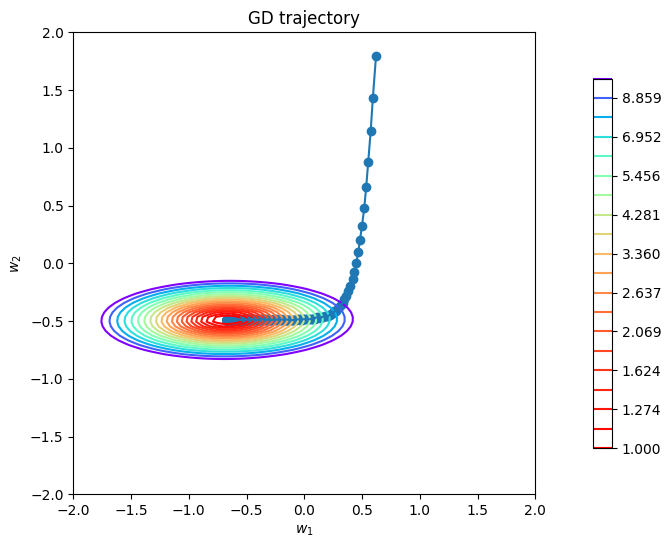

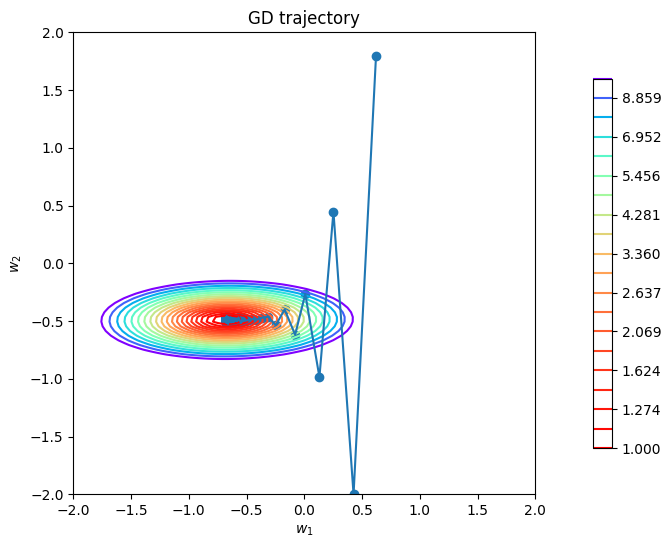

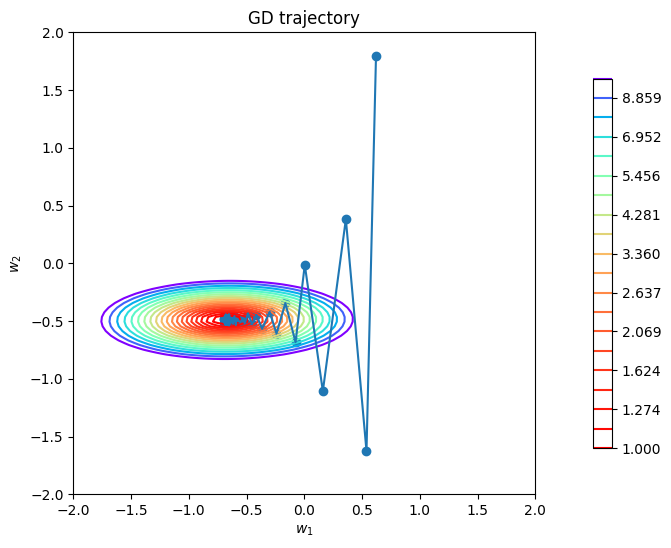

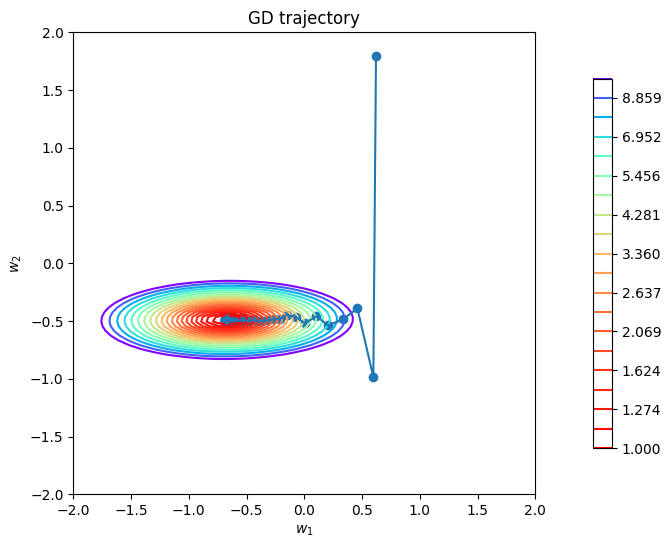

In [11]:
w = stochastic_gradient_descent(w_init, X, y, loss, 0.0001, 100)
plot_gd(w, X, y, loss)
w = stochastic_gradient_descent(w_init, X, y, loss, 0.0001, 10)
plot_gd(w, X, y, loss)
w = stochastic_gradient_descent(w_init, X, y, loss, 0.001, 160)
plot_gd(w, X, y, loss)
w = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 170)
plot_gd(w, X, y, loss)
w = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 100)
plot_gd(w, X, y, loss)
w= stochastic_gradient_descent(w_init, X, y, loss, 0.008, 120)
plot_gd(w, X, y, loss)# -- YOUR CODE HERE -- ٩(⁎❛ᴗ❛⁎)۶

При уменьшении lr модель будет медленнее обучаться (так как нужно будет сделать больше шагов), однако не будет риска того, что модель перепрыгнет минимум (однако есть возможность, что модель может "застрять" в локальном минимуме, но здесь их вроде нет). При увеличении batch_size шаги становятся более точными, при маленьком размере batch_size, есть вероятность, что мы пойдем не туда. Стохастический градиентный спуск будет быстрее обычного градиентного спуска, также по графикам можно заметить, что он более зигзагообразный (это помогает избегать локальных минимумов).

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [12]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    s0=1
    w=w_init
    w_history=[w]
    for t in range(1,n_iterations+1):
      indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
      X_batch = X[indices]
      y_batch = y[indices]
      grad = loss.calc_grad(X_batch, y_batch, w)
      eta = lr * (s0 / (s0 + t)) ** p
      w = w - eta * grad
      w_history.append(w)

    return w_history
    # -- YOUR CODE HERE -- ¯\_(ツ)_/¯

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

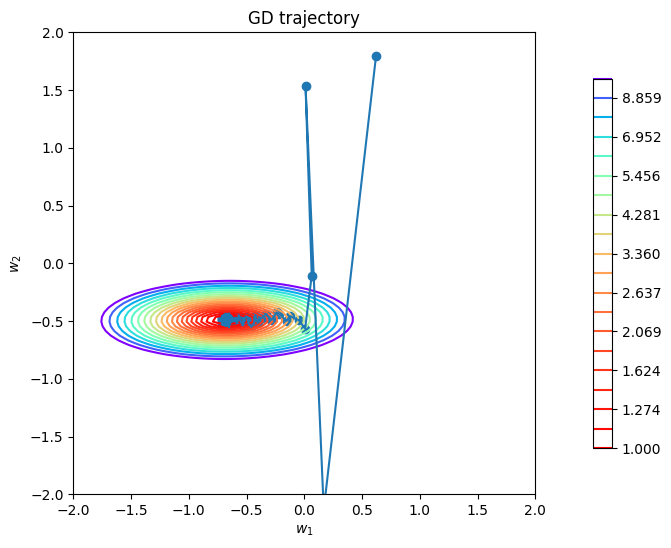

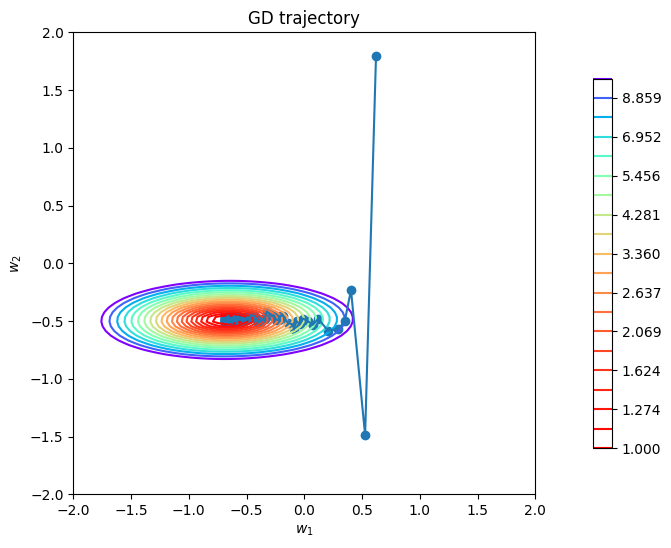

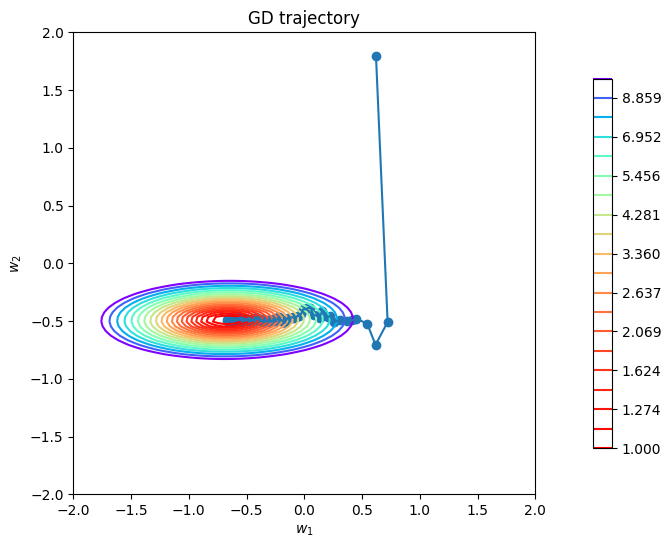

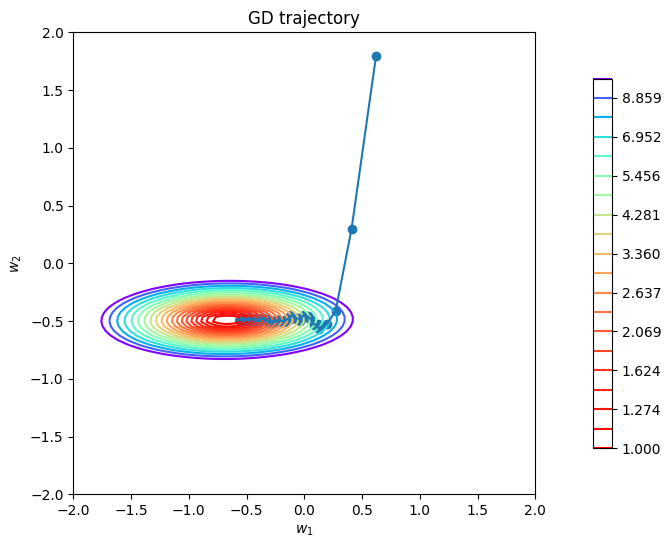

In [13]:
w = stochastic_gradient_descent(w_init, X, y, loss, lr=0.01, batch_size=10, p=0.2)
plot_gd(w, X, y, loss)
w = stochastic_gradient_descent(w_init, X, y, loss, lr=0.01, batch_size=10, p=0.4)
plot_gd(w, X, y, loss)
w = stochastic_gradient_descent(w_init, X, y, loss, lr=0.01, batch_size=10, p=0.6)
plot_gd(w, X, y, loss)
w = stochastic_gradient_descent(w_init, X, y, loss, lr=0.01, batch_size=10, p=0.8)
plot_gd(w, X, y, loss)# -- YOUR CODE HERE -- [✖‿✖]

По графикам можно заметить, что при больших p мы идем медленнее, однако сходимость будет более точной. Также по первым графикам для меньших p видно, что путь более извилистый, чем при больших p. Это все логично, так как при увеличении p мы с большей скоростью уменьшаем длину шага.

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

In [14]:
loss = MSELoss()

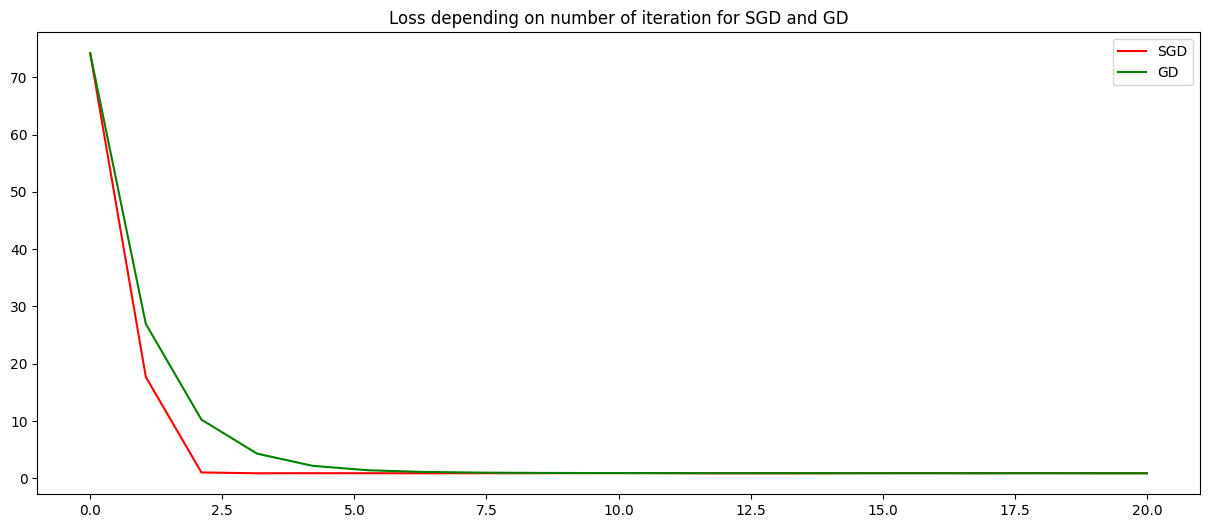

In [15]:
w_init = np.random.randn(X.shape[1])
w_gd = gradient_descent(w_init,X, y, loss, 0.01, n_iterations=20)
w_sgd = stochastic_gradient_descent(w_init,X, y, loss, 0.01, batch_size=10, p=0.5, n_iterations=20)
sgd= []
gd = []
for i in range(len(w_sgd)-1):
    sgd.append(loss.calc_loss(X, y, w_sgd[i]))
    gd.append(loss.calc_loss(X, y, w_gd[i]))
plt.figure(figsize=(15, 6))
plt.title('Loss depending on number of iteration for SGD and GD')
plt.plot(np.linspace(0,len(sgd),len(sgd)) ,sgd, color='red' ,label="SGD")
plt.plot(np.linspace(0,len(gd),len(gd)),gd, color='green', label="GD")
plt.legend()

На графике видно преимущество SGD -- он быстрее стремится к нулю. Думаю это происходит, так как SGD чаще обновляет веса. Еще каждая итерация стохастического градинтного спуска в несколько раз быстрее обычного (так как используем batches).Также можно заметить, что график для обычного градиентного спуска более плавный.

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [16]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        self.w = np.random.randn(X.shape[1])
        w_history = gradient_descent(w_init=self.w,X=X,y=y,loss=self.loss, lr=self.lr)
        self.w = w_history[-1]


        # -- YOUR CODE HERE -- ʕ•ᴥ•ʔ

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        return np.dot(X,self.w)

        # -- YOUR CODE HERE -- ٩(⁎❛ᴗ❛⁎)۶

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [17]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [18]:
import pandas as pd

X_raw = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [19]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

Посмотрим датафрейм на типы данных и пропуски:

In [20]:
df=pd.DataFrame(data=X_raw)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       201 non-null    int64  
 1   2       164 non-null    float64
 2   3       201 non-null    object 
 3   4       201 non-null    object 
 4   5       201 non-null    object 
 5   6       199 non-null    object 
 6   7       201 non-null    object 
 7   8       201 non-null    object 
 8   9       201 non-null    object 
 9   10      201 non-null    float64
 10  11      201 non-null    float64
 11  12      201 non-null    float64
 12  13      201 non-null    float64
 13  14      201 non-null    int64  
 14  15      201 non-null    object 
 15  16      201 non-null    object 
 16  17      201 non-null    int64  
 17  18      201 non-null    object 
 18  19      197 non-null    float64
 19  20      197 non-null    float64
 20  21      201 non-null    float64
 21  22      199 non-null    float64
 22  23

In [21]:
df.isnull().sum()

,0
1,0
2,37
3,0
4,0
5,0
6,2
7,0
8,0
9,0
10,0


In [22]:
df[6].unique()

array(['two', 'four', nan], dtype=object)

Видим пропуски во 2,6,19, 20, 22 и 23 столбце. Все, кроме 6 столбца -- числовые признаки, 6 столбец -- категориальный. Предлагю заполнить пропуски в числовых столбцах медианным значением, а в категориальном заменим пропуски на 'unknown' (так как значения в этом стобце 'two' и 'four', то я не вижу другого логичного заполнения).

In [23]:
df[6]=df[6].fillna('unknown')
for i in [2,19,20,22,23]:
  df[i]=df[i].fillna(df[i].median())

Проверим,что пропуски удалены:

In [24]:
df.isnull().sum()

,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0
10,0


Разделим признаки на категориальные и числовые:

In [25]:
categorical=[3,4,5,6,7,8,9,15,16,18]
numerics=[1,2,10,11,12,13,14,17,19,20,21,22,23,24,25]

Закодируем категориальные признаки с помощью OHE:

In [26]:
df= pd.get_dummies(df, columns=categorical, drop_first=True)



Числовые признаки обработаем с помощью Scaler:

In [27]:
scaler = StandardScaler()
scaler.fit(df[numerics])
df[numerics]=scaler.transform(df[numerics])


Разобьем на тренировочную и тестовую выборку:

In [28]:
np.random.seed(42)
x_train, x_test, y_train, y_test = train_test_split(df, y, test_size=0.3)

**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [29]:
linear_regression.fit(x_train, y_train)

In [30]:
# -- YOUR CODE HERE -- (ﾉ´ з `)ノ

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [31]:
train_predictions = linear_regression.predict(x_train)
test_predictions = linear_regression.predict(x_test)
mse_lr_train=round(mean_squared_error(y_train, train_predictions),2)
mse_lr_test=round(mean_squared_error(y_test, test_predictions),2)
print( mse_lr_train,mse_lr_test)
data={'Model':[],'Train':[],'Test':[]}
data=pd.DataFrame(data)
data.loc[len(data)]=['LR',mse_lr_train, mse_lr_test]
# -- YOUR CODE HERE -- ( ⚆ ω ⚆)

1336997.99 9279041.08


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [32]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        z=np.dot(X,w)-y
        return (1/len(y)) * (z**2).sum() + self.coef*np.sum(w[:-1]**2)
        # -- YOUR CODE HERE -- (´｡• ᵕ •｡`)
        # Вычислите значение функции потерь при помощи X, y и w и верните его

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        w_bias=w.copy()
        w_bias[-1]=0
        z=np.dot(X,w)-y
        return (2/len(y)) * np.dot(X.T,z) + 2*self.coef*w_bias
        # -- YOUR CODE HERE -- (￢_￢)
        # Вычислите значение вектора градиента при помощи X, y и w и верните его

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [33]:
linear_regression = LinearRegression(MSEL2Loss(0.01))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [34]:
linear_regression.fit(x_train, y_train)
train_predictions = linear_regression.predict(x_train)
test_predictions = linear_regression.predict(x_test)
mse_loss_train=round(mean_squared_error(y_train, train_predictions),2)
mse_loss_test=round(mean_squared_error(y_test, test_predictions),2)
print( mse_loss_train,mse_loss_test)
data.loc[len(data)]=['Loss',mse_loss_train, mse_loss_test]

2581245.43 8014683.13


In [35]:
data

,Model,Train,Test
0,LR,1336997.99,9279041.08
1,Loss,2581245.43,8014683.13


Видим, что нам удалось улучшить наш результат mse как на тестовой выборке, однако на тренировочной лучший результат показала модель без регуляризации.

В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [36]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        z = np.dot(X,w) - y
        if abs(np.linalg.norm(z)) < self.eps :
            return (np.linalg.norm(0.5*z))/len(y)
        else:
            return np.linalg.norm(self.eps*(np.linalg.norm(z)-self.eps*0.5))
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        # -- YOUR CODE HERE -- (っ˘ڡ˘ς)
        # Вычислите значение функции потерь при помощи X, y и w и верните его

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        z = np.dot(X,w)- y
        if np.linalg.norm(z) < self.eps:
            return np.dot(X,w)/len(y)
        else:
            return np.dot(X.T,(self.eps*np.sign(z)))/len(y)
        # -- YOUR CODE HERE -- ٩(ˊ〇ˋ*)و
        # Вычислите значение вектора градиента при помощи X, y и w и верните его

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [37]:
linear_regression = LinearRegression(HuberLoss(eps=100))
linear_regression.fit(x_train, y_train)
train_predictions = linear_regression.predict(x_train)
test_predictions = linear_regression.predict(x_test)
mse_huber_train=round(mean_squared_error(y_train, train_predictions),2)
mse_huber_test=round(mean_squared_error(y_test, test_predictions),2)
data.loc[len(data)]=['Huber',mse_huber_train, mse_huber_test]# -- YOUR CODE HERE -- (＠_＠)

In [38]:
data

,Model,Train,Test
0,LR,1336997.99,9279041.08
1,Loss,2581245.43,8014683.13
2,Huber,2286954.23,7255769.22


Видим, что в итоге лучше всего mse на тестовой выборке получилась у линейной регрессии с huber loss -- значения у Huber Loss значительно ниже, чем у первых двух моделей. Однако на тренировочной выборке показатель меньше всего у первой модели обученной без L2 регуляризации.

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

In [40]:
# -- YOUR MEME HERE -- ╰( ͡° ͜ʖ ͡° )つ▬▬ι═══════  bzzzzzzzzzz

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

Пользовалась этими ресурсами: https://habr.com/ru/articles/209610/, https://www.mql5.com/ru/articles/13851#tag2.

In [41]:
class Imitation:
    def __init__(self, n_features, temp_init=100, temp_decay=0.9, t_df=3):
        """
        :param n_features: количество признаков
        :param temp_init: начальная температура
        :param temp_decay: скорость охлаждения
        :param t_df: степени свободы для распределения
        """
        self.temp = temp_init
        self.temp_decay = temp_decay
        self.t_df = t_df
        self.w = np.random.randn(n_features)
        self.loss = []

    def mse_loss(self, X, y):
        return np.mean((np.dot(X,self.w) - y)**2)

    def fit(self, X, y, n_iterations=1000):
        current_loss = self.mse_loss(X, y)
        self.loss.append(current_loss)
        for i in range(n_iterations):
            new_w=self.w+np.random.standard_t(3, size=self.w.shape)
            new_loss = np.mean((np.dot(X , new_w) - y)**2)
            if new_loss < current_loss:
                self.w = new_w
                current_loss = new_loss
            else:
                if np.random.rand() < np.exp(-(new_loss - current_loss)/self.temp):
                    self.w = new_w
                    current_loss = new_loss

            self.temp *= self.temp_decay
            self.loss.append(current_loss)

        return self# -- YOUR CODE HERE -- ʕ•ᴥ•ʔ

Сравнить с градиентным спуском не успела...